In [2]:
# Cell 1: Imports, seed, and global config

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

warnings.filterwarnings("ignore")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Assignment-compliant reduced-compute settings
N_CLIENTS = 50
CLIENTS_PER_ROUND = 10
ROUNDS = 100
LOCAL_EPOCHS = 3
BATCH_SIZE = 32
CANDIDATE_POOL_SIZE = 20
PROXY_VAL_SIZE = 5000

# Task 1 / Task 2 model list
MODEL_NAMES = ["simple_cnn", "logreg", "svm", "rf", "lenet"]
STRATEGIES = ["greedy", "shapley"]

# Task 2: choose one drift scenario to run first
DRIFT_SCENARIO = "gradual_feature_shift"
# Other options supported:
# "sudden_feature_shift", "gradual_label_shift", "sudden_label_shift", "mixed_drift"

K_VALUES = [5, 10, 20]

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [3]:
# Cell 2: Load MNIST and prepare train / proxy / test splits

(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
y_train_full = y_train_full.astype(np.int64)
y_test = y_test.astype(np.int64)

# Flattened versions for classical ML models
X_train_full_flat = x_train_full.reshape(-1, 28 * 28)
X_test_flat = x_test.reshape(-1, 28 * 28)

# Image versions for CNN / LeNet
X_train_full_img = x_train_full.reshape(-1, 28, 28, 1)
X_test_img = x_test.reshape(-1, 28, 28, 1)

# Split off a proxy validation set for client scoring
X_pool_flat, X_proxy_flat, y_pool, y_proxy = train_test_split(
    X_train_full_flat,
    y_train_full,
    test_size=PROXY_VAL_SIZE,
    random_state=SEED,
    stratify=y_train_full
)

X_pool_img = X_pool_flat.reshape(-1, 28, 28, 1)
X_proxy_img = X_proxy_flat.reshape(-1, 28, 28, 1)

# Standardize classical features
scaler = StandardScaler()
X_pool_scaled = scaler.fit_transform(X_pool_flat)
X_proxy_scaled = scaler.transform(X_proxy_flat)
X_test_scaled = scaler.transform(X_test_flat)

classes = np.arange(10)

print("Pool:", X_pool_flat.shape, "Proxy:", X_proxy_flat.shape, "Test:", X_test_flat.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Pool: (55000, 784) Proxy: (5000, 784) Test: (10000, 784)


In [4]:
# Cell 3: Non-IID client partition for 50 clients

def shard_partition(y, n_clients=50, shards_per_client=4, seed=SEED):
    """
    Non-IID shard split:
    - sort by label
    - split into n_clients * shards_per_client shards
    - assign a few shards to each client
    """
    rng = np.random.default_rng(seed)
    idx_sorted = np.argsort(y)
    n_shards = n_clients * shards_per_client
    shards = np.array_split(idx_sorted, n_shards)
    rng.shuffle(shards)

    client_indices = []
    for i in range(n_clients):
        chunk = shards[i * shards_per_client:(i + 1) * shards_per_client]
        client_indices.append(np.concatenate(chunk))
    return client_indices

def client_label_histograms(y, client_indices, n_classes=10):
    hists = np.zeros((len(client_indices), n_classes), dtype=np.float32)
    for cid, idx in enumerate(client_indices):
        counts = np.bincount(y[idx], minlength=n_classes).astype(np.float32)
        hists[cid] = counts / (counts.sum() + 1e-9)
    return hists

client_indices = shard_partition(y_pool, n_clients=N_CLIENTS, shards_per_client=4, seed=SEED)
client_hists = client_label_histograms(y_pool, client_indices)

print("Number of clients:", len(client_indices))
print("Samples per client (first 5):", [len(client_indices[i]) for i in range(5)])

Number of clients: 50
Samples per client (first 5): [1100, 1100, 1100, 1100, 1100]


In [5]:
# Cell 4: Greedy diversity selection and Shapley-style proxy scoring

def cosine_distance(a, b):
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-9
    return 1.0 - float(np.dot(a, b) / denom)

def greedy_diverse_select(candidate_clients, k, hists):
    """
    DivFL-style greedy diversity selection.
    """
    candidate_clients = list(candidate_clients)
    if len(candidate_clients) <= k:
        return candidate_clients

    selected = [candidate_clients[0]]
    remaining = [c for c in candidate_clients if c not in selected]

    while len(selected) < k and remaining:
        best_client = None
        best_score = -1.0
        for cid in remaining:
            score = min(cosine_distance(hists[cid], hists[s]) for s in selected)
            if score > best_score:
                best_score = score
                best_client = cid
        selected.append(best_client)
        remaining.remove(best_client)

    return selected

def compute_proxy_scores(client_indices, X_train_scaled, y_train, X_val_scaled, y_val, sample_per_client=200):
    """
    Practical proxy for Shapley-style client usefulness:
    - Train a small proxy classifier on each client's local data
    - Measure proxy validation accuracy
    """
    scores = {}
    rng = np.random.default_rng(SEED)

    for cid, idx in enumerate(client_indices):
        if len(idx) < 20:
            scores[cid] = 0.0
            continue

        use_idx = idx
        if len(use_idx) > sample_per_client:
            use_idx = rng.choice(use_idx, size=sample_per_client, replace=False)

        y_local = y_train[use_idx]
        if len(np.unique(y_local)) < 2:
            scores[cid] = 0.0
            continue

        proxy_clf = SGDClassifier(
            loss="log_loss",
            alpha=1e-4,
            max_iter=10,
            tol=None,
            random_state=SEED
        )

        try:
            proxy_clf.fit(X_train_scaled[use_idx], y_local)
            pred = proxy_clf.predict(X_val_scaled)
            scores[cid] = accuracy_score(y_val, pred)
        except Exception:
            scores[cid] = 0.0

    return scores

client_proxy_scores = compute_proxy_scores(
    client_indices,
    X_pool_scaled,
    y_pool,
    X_proxy_scaled,
    y_proxy,
    sample_per_client=200
)

def shapley_like_select(candidate_clients, k, proxy_scores):
    ranked = sorted(candidate_clients, key=lambda c: proxy_scores.get(c, 0.0), reverse=True)
    return ranked[:k]

print("Proxy score sample:", {i: round(client_proxy_scores[i], 4) for i in range(5)})

Proxy score sample: {0: 0.3712, 1: 0.374, 2: 0.3704, 3: 0.3618, 4: 0.3844}


In [6]:
# Cell 5: Models

def build_simple_cnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def build_lenet():
    """
    LeNet-style CNN for MNIST.
    """
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(6, (5, 5), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(16, (5, 5), activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(120, activation="relu"),
        tf.keras.layers.Dense(84, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def build_logreg():
    return LogisticRegression(
        max_iter=300,
        solver="lbfgs",
        n_jobs=-1,
        random_state=SEED
    )

def build_svm():
    return SGDClassifier(
        loss="hinge",
        alpha=1e-4,
        max_iter=1,
        tol=None,
        learning_rate="optimal",
        random_state=SEED
    )

def build_rf():
    return RandomForestClassifier(
        n_estimators=30,
        random_state=SEED,
        n_jobs=-1
    )

In [7]:
# Cell 6: Data helpers for one round

CNN_MODELS = {"simple_cnn", "lenet"}

def get_candidate_clients(round_idx, candidate_pool_size=CANDIDATE_POOL_SIZE):
    rng = np.random.default_rng(SEED + round_idx)
    return rng.choice(
        N_CLIENTS,
        size=min(candidate_pool_size, N_CLIENTS),
        replace=False
    ).tolist()

def get_selected_clients(candidate_clients, strategy, k, hists, proxy_scores):
    if strategy == "greedy":
        return greedy_diverse_select(candidate_clients, k, hists)
    if strategy == "shapley":
        return shapley_like_select(candidate_clients, k, proxy_scores)
    raise ValueError(f"Unknown strategy: {strategy}")

def get_round_data(selected_clients, drift_scenario=None, round_idx=0, total_rounds=ROUNDS):
    idx = np.concatenate([client_indices[c] for c in selected_clients])

    X_round_img = X_pool_img[idx].copy()
    y_round = y_pool[idx].copy()

    if drift_scenario is not None:
        X_round_img = apply_feature_drift(X_round_img, round_idx, total_rounds, drift_scenario)
        y_round = apply_label_drift(y_round, round_idx, total_rounds, drift_scenario)

    X_round_flat = X_round_img.reshape(-1, 28 * 28)
    X_round_scaled = scaler.transform(X_round_flat)

    return X_round_scaled, X_round_img, y_round

def get_eval_data(drift_scenario=None, round_idx=0, total_rounds=ROUNDS):
    X_eval_img = X_test_img.copy()
    y_eval = y_test.copy()

    if drift_scenario is not None:
        X_eval_img = apply_feature_drift(X_eval_img, round_idx, total_rounds, drift_scenario)
        y_eval = apply_label_drift(y_eval, round_idx, total_rounds, drift_scenario)

    X_eval_flat = X_eval_img.reshape(-1, 28 * 28)
    X_eval_scaled = scaler.transform(X_eval_flat)

    return X_eval_scaled, X_eval_img, y_eval

def evaluate_model(model_name, model, drift_scenario=None, round_idx=0, total_rounds=ROUNDS):
    X_eval_scaled, X_eval_img, y_eval = get_eval_data(drift_scenario, round_idx, total_rounds)

    if model_name in CNN_MODELS:
        probs = model.predict(X_eval_img, verbose=0)
        preds = np.argmax(probs, axis=1)
    else:
        preds = model.predict(X_eval_scaled)

    return accuracy_score(y_eval, preds)

In [8]:
# Cell 7: Training helper for one round

def train_one_round(model_name, model, X_round_scaled, X_round_img, y_round):
    unique_classes = np.unique(y_round)

    if model_name == "simple_cnn":
        if model is None:
            model = build_simple_cnn()
        model.fit(X_round_img, y_round, epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, verbose=0)
        return model

    if model_name == "lenet":
        if model is None:
            model = build_lenet()
        model.fit(X_round_img, y_round, epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, verbose=0)
        return model

    if model_name == "logreg":
        if len(unique_classes) < 2:
            if model is None:
                dummy = DummyClassifier(strategy="most_frequent")
                dummy.fit(X_round_scaled, y_round)
                return dummy
            return model
        model = build_logreg()
        model.fit(X_round_scaled, y_round)
        return model

    if model_name == "svm":
        if model is None or not hasattr(model, "classes_"):
            model = build_svm()
            model.partial_fit(X_round_scaled, y_round, classes=classes)
        else:
            model.partial_fit(X_round_scaled, y_round)
        return model

    if model_name == "rf":
        if len(unique_classes) < 2:
            if model is None:
                dummy = DummyClassifier(strategy="most_frequent")
                dummy.fit(X_round_scaled, y_round)
                return dummy
            return model
        model = build_rf()
        model.fit(X_round_scaled, y_round)
        return model

    raise ValueError(f"Unknown model: {model_name}")

In [9]:
# Cell 8: Generic federated experiment runner for Task 1 and Task 2

def run_experiment(
    model_name,
    strategy,
    rounds=ROUNDS,
    k=CLIENTS_PER_ROUND,
    candidate_pool_size=CANDIDATE_POOL_SIZE,
    drift_scenario=None
):
    model = None
    acc_history = []
    comm_history = []
    comp_history = []

    for r in range(rounds):
        candidate_clients = get_candidate_clients(r, candidate_pool_size)
        selected_clients = get_selected_clients(
            candidate_clients,
            strategy,
            k,
            client_hists,
            client_proxy_scores
        )

        X_round_scaled, X_round_img, y_round = get_round_data(
            selected_clients,
            drift_scenario=drift_scenario,
            round_idx=r,
            total_rounds=rounds
        )

        model = train_one_round(model_name, model, X_round_scaled, X_round_img, y_round)

        acc = evaluate_model(model_name, model, drift_scenario=drift_scenario, round_idx=r, total_rounds=rounds)
        acc_history.append(acc)
        comm_history.append((r + 1) * k)
        comp_history.append((r + 1) * k * LOCAL_EPOCHS)

        if (r == 0) or ((r + 1) % 10 == 0):
            tag = "DRIFT" if drift_scenario is not None else "BASE"
            print(f"[{tag} | {model_name} | {strategy} | K={k}] round {r+1:03d}/{rounds}  acc={acc:.4f}")

    return model, acc_history, comm_history, comp_history

In [10]:
# Cell 9: Task 1 experiments

task1_results = {}

for model_name in MODEL_NAMES:
    for strategy in STRATEGIES:
        print(f"\n=== Task 1: {model_name} with {strategy} ===")
        _, acc_hist, comm_hist, comp_hist = run_experiment(
            model_name=model_name,
            strategy=strategy,
            rounds=ROUNDS,
            k=CLIENTS_PER_ROUND,
            candidate_pool_size=CANDIDATE_POOL_SIZE,
            drift_scenario=None
        )
        task1_results[(model_name, strategy)] = {
            "accuracy": acc_hist,
            "communication": comm_hist,
            "computation": comp_hist
        }


=== Task 1: simple_cnn with greedy ===
[BASE | simple_cnn | greedy | K=10] round 001/100  acc=0.9812
[BASE | simple_cnn | greedy | K=10] round 010/100  acc=0.9906
[BASE | simple_cnn | greedy | K=10] round 020/100  acc=0.9906
[BASE | simple_cnn | greedy | K=10] round 030/100  acc=0.9894
[BASE | simple_cnn | greedy | K=10] round 040/100  acc=0.9912
[BASE | simple_cnn | greedy | K=10] round 050/100  acc=0.9914
[BASE | simple_cnn | greedy | K=10] round 060/100  acc=0.9914
[BASE | simple_cnn | greedy | K=10] round 070/100  acc=0.9916
[BASE | simple_cnn | greedy | K=10] round 080/100  acc=0.9913
[BASE | simple_cnn | greedy | K=10] round 090/100  acc=0.9927
[BASE | simple_cnn | greedy | K=10] round 100/100  acc=0.9922

=== Task 1: simple_cnn with shapley ===
[BASE | simple_cnn | shapley | K=10] round 001/100  acc=0.9784
[BASE | simple_cnn | shapley | K=10] round 010/100  acc=0.9895
[BASE | simple_cnn | shapley | K=10] round 020/100  acc=0.9912
[BASE | simple_cnn | shapley | K=10] round 030/1

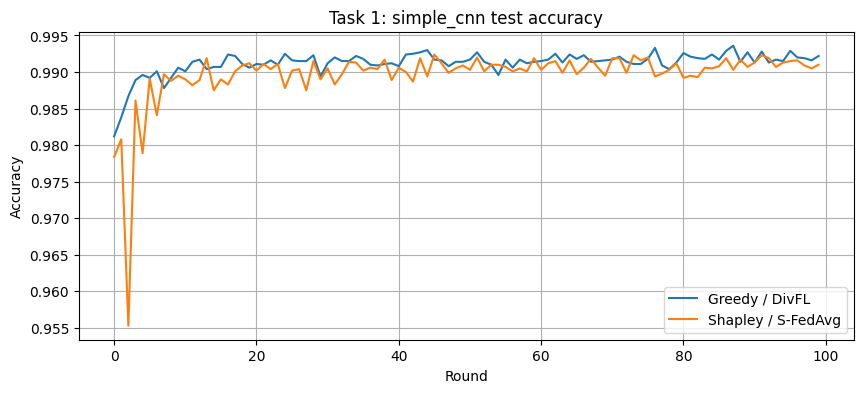

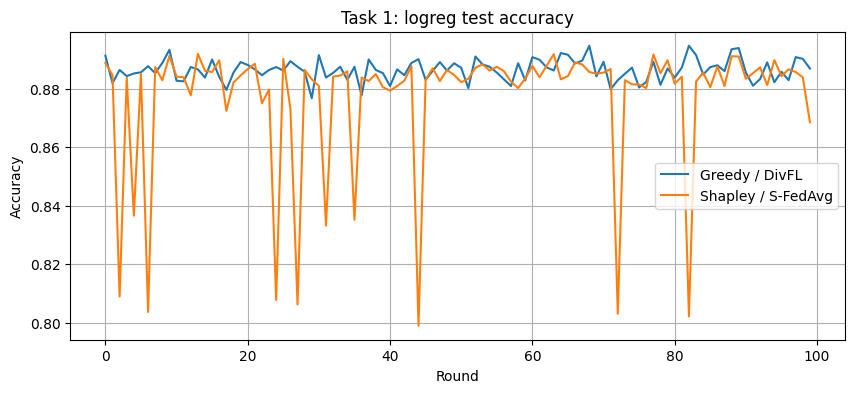

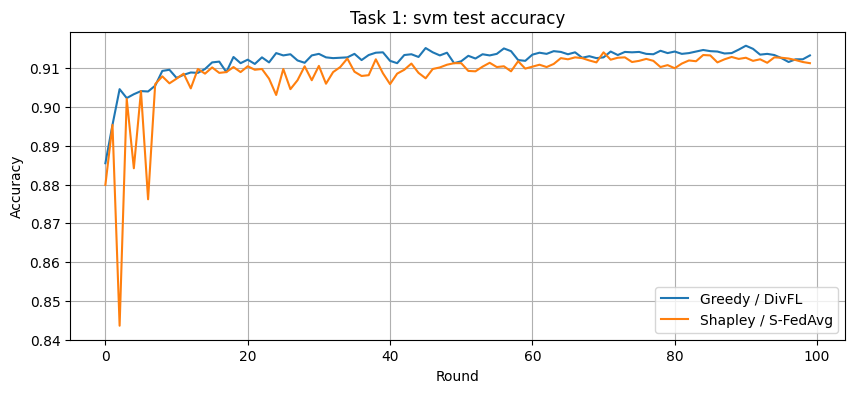

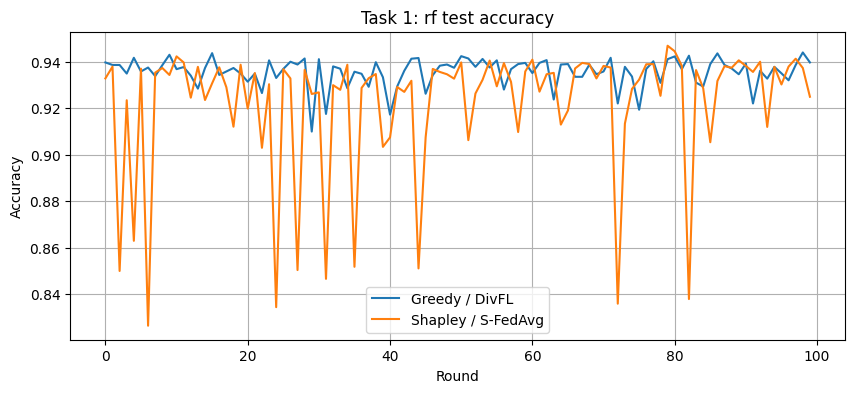

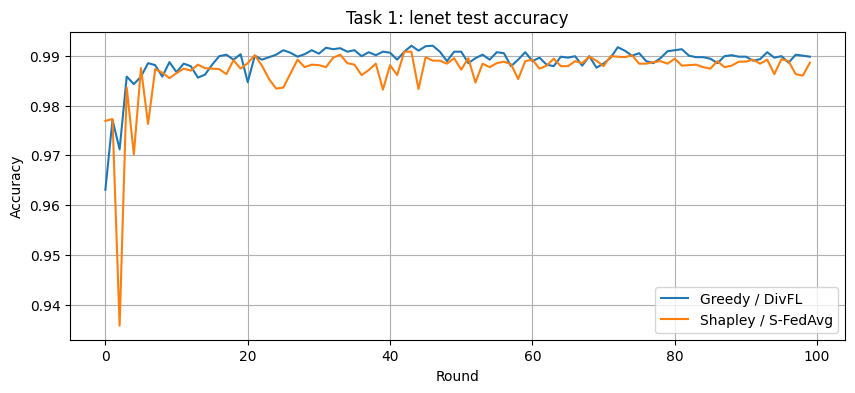

In [11]:
# Cell 10: Task 1 plots

for model_name in MODEL_NAMES:
    plt.figure(figsize=(10, 4))
    plt.plot(task1_results[(model_name, "greedy")]["accuracy"], label="Greedy / DivFL")
    plt.plot(task1_results[(model_name, "shapley")]["accuracy"], label="Shapley / S-FedAvg")
    plt.title(f"Task 1: {model_name} test accuracy")
    plt.xlabel("Round")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [12]:
# Cell 11: Task 1 summary table

def first_round_reaching_threshold(history, threshold=0.80):
    for i, acc in enumerate(history, start=1):
        if acc >= threshold:
            return i
    return None

task1_summary = []

for model_name in MODEL_NAMES:
    for strategy in STRATEGIES:
        hist = task1_results[(model_name, strategy)]["accuracy"]
        task1_summary.append({
            "model": model_name,
            "strategy": strategy,
            "final_accuracy": hist[-1],
            "best_accuracy": max(hist),
            "mean_accuracy": float(np.mean(hist)),
            "round_to_80pct": first_round_reaching_threshold(hist, 0.80),
            "communication_cost": ROUNDS * CLIENTS_PER_ROUND,
            "computation_cost_units": ROUNDS * CLIENTS_PER_ROUND * LOCAL_EPOCHS
        })

task1_summary_df = pd.DataFrame(task1_summary).sort_values(["model", "strategy"]).reset_index(drop=True)
task1_summary_df

,model,strategy,final_accuracy,best_accuracy,mean_accuracy,round_to_80pct,communication_cost,computation_cost_units
0,lenet,greedy,0.9898,0.9920,0.988959,1,1000,3000
1,lenet,shapley,0.9886,0.9908,0.986899,1,1000,3000
2,logreg,greedy,0.8870,0.8948,0.886549,1,1000,3000
3,logreg,shapley,0.8686,0.8920,0.877501,1,1000,3000
4,rf,greedy,0.9398,0.9441,0.935737,1,1000,3000
5,rf,shapley,0.9250,0.9470,0.922392,1,1000,3000
6,simple_cnn,greedy,0.9922,0.9936,0.991230,1,1000,3000
7,simple_cnn,shapley,0.9910,0.9924,0.989656,1,1000,3000
8,svm,greedy,0.9133,0.9158,0.911931,1,1000,3000
9,svm,shapley,0.9113,0.9141,0.908418,1,1000,3000
